In [30]:
import numpy as np

import sys
sys.path.append('/home/mark.bishop/Documents/Kea')
import kea
from kea.statistics.spectra import fourier_modal_spectrum, bt_modal_spectrum, esf_integrated_spectrum
from kea.statistics.statfunc import complete_symmetric_correlation_function, structure_function
from kea.simulator import mff


from kea.utils import geometry

import matplotlib.pyplot as plt

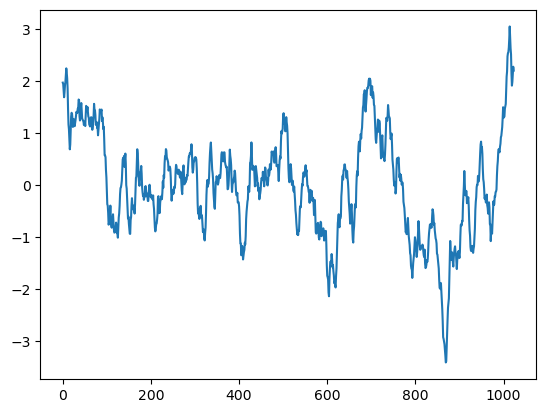

In [31]:
D = 1
N = 1024
kk = mff.make_grid(N, D)
field = mff.make_mff(kk[1], 2.*np.pi, 2./3., N)
plt.plot(field)

In [32]:
geometry.DEFAULT_PHYS_SCALE = 3.*np.pi
dx, dk = geometry.get_dxdk((N,)*D)
print(dx)

(0.009203884727313847,)


In [33]:
kp, fekp = fourier_modal_spectrum(field)

In [34]:
ell, acf_full = complete_symmetric_correlation_function(field)
kc, fekc = bt_modal_spectrum(acf_full)

In [35]:
ell, sf = structure_function(field)
ks, _, feks = esf_integrated_spectrum(ell[:,0]*dx[0], sf[:,0], D)

/home/mark.bishop/Documents/Kea/kea/statistics/spectra/equiv_spectrum.py:81: RuntimeWarning: divide by zero encountered in divide
  ke = b / ell
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:699: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


(1e-06, 10.0)

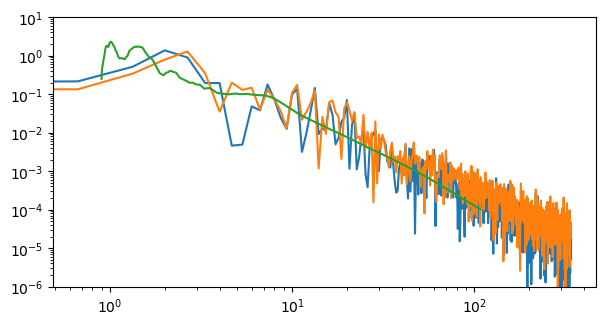

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(7., 3.5))

ax.plot(kp[0], fekp)
ax.plot(kc[0], fekc)

ax.plot(ks, 2.*feks)

ax.loglog()

ax.set_ylim((1e-6, 1e1))